# Pakistan Navy Eligibility Predictor
## Model Evaluation Notebook

We load the saved `best_model.pkl` and measure:
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

### 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)


### 2. Load the dataset and the saved model

In [2]:
df = pd.read_csv('../data/navy_dataset.csv')
model = joblib.load('../model/best_model.pkl')
print('Data loaded:', df.shape)
print('Model loaded successfully.')


Data loaded: (8500, 17)
Model loaded successfully.


### 3. Recreate the same train-test split
We use the same `random_state=42` so the test set matches training.

In [3]:
y = df['eligibility_status']
X = df.drop(columns=['candidate_id', 'eligibility_status'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### 4. Make predictions on the test set

In [4]:
y_pred = model.predict(X_test)
y_pred[:10]


array(['Eligible', 'Not Eligible', 'Not Eligible', 'Eligible', 'Eligible',
       'Not Eligible', 'Not Eligible', 'Eligible', 'Not Eligible',
       'Not Eligible'], dtype=object)

### 5. Main scores
We treat **'Eligible'** as the positive class.

In [5]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label='Eligible')
rec = recall_score(y_test, y_pred, pos_label='Eligible')
f1 = f1_score(y_test, y_pred, pos_label='Eligible')

print(f'Accuracy : {acc:.3f}')
print(f'Precision: {prec:.3f}')
print(f'Recall   : {rec:.3f}')
print(f'F1 Score : {f1:.3f}')


Accuracy : 0.982
Precision: 0.969
Recall   : 0.991
F1 Score : 0.980


### 6. Full classification report

In [6]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    Eligible       0.97      0.99      0.98       737
Not Eligible       0.99      0.98      0.98       963

    accuracy                           0.98      1700
   macro avg       0.98      0.98      0.98      1700
weighted avg       0.98      0.98      0.98      1700



### 7. Confusion Matrix

Confusion matrix:
[[730   7]
 [ 23 940]]


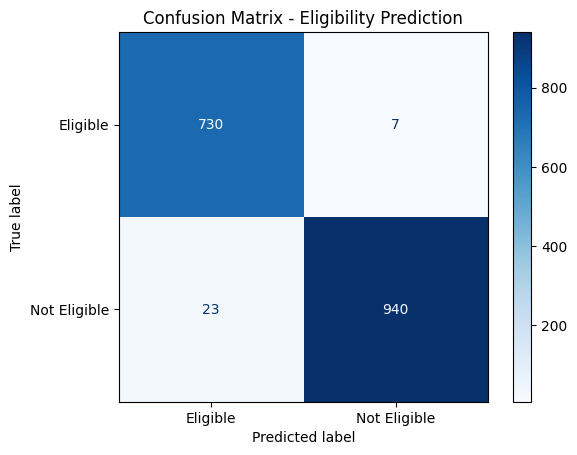

In [7]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
print('Confusion matrix:')
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Eligibility Prediction')
plt.show()


### 8. Summary table

In [8]:
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [acc, prec, rec, f1]
})
summary


,Metric,Score
0,Accuracy,0.982353
1,Precision,0.969456
2,Recall,0.990502
3,F1 Score,0.979866


Evaluation complete. These scores can go straight into your project report.